# Notebook 3

This notebook will work with escape regions instead of calculating intersection points

## 2 Dimensions

(It might be extended later)

In [6]:
import numpy as np
from stage_escape.brownian import BrownianMotion
from stage_escape.surface import Surface
from stage_escape.escape import Escape
from stage_escape.equivalent_narrow_escape import EquivalentNarrowEscape
from stage_escape.statistics import Statistics
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from scipy.special import gamma

In [7]:
deposition_stride = 10000
DELTA_T = 0.0001
DIMENSION = 2
SEED = 42  # Set a seed for reproducibility

Escape time: 1.5963


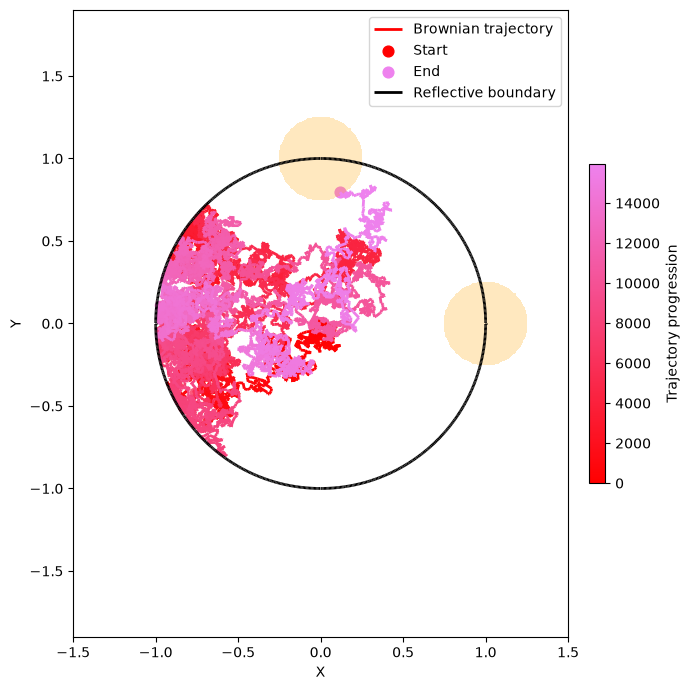

In [18]:
bm = BrownianMotion(deposition_stride=deposition_stride, delta_t=DELTA_T, dimension=DIMENSION, seed=SEED)

# Surface defined by the equation x^2 + y^2 = 1 (unit circle)
surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

point1 = np.array([1, 0])
escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** 2) <= (0.5 / 2) ** 2]) # Escape region

point2 = np.array([0, 1])
escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** 2) <= (0.5 / 2) ** 2])

narrow_escape = EquivalentNarrowEscape(bm, surface, [escape1, escape2])

escape_point, escape_time = narrow_escape.run_simulation()
print(f'Escape time: {escape_time}')
narrow_escape.plot_narrow_escape_problem()


In [19]:
def run_one_simulation_2d(epsilon1, epsilon2):
    bm = BrownianMotion(deposition_stride=deposition_stride, delta_t=DELTA_T, dimension=DIMENSION)

    # Surface defined by the equation x^2 + y^2 = 1 (unit circle)
    surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

    point1 = np.array([1, 0])
    escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** 2) <= (epsilon1 / 2) ** 2]) # Escape region

    point2 = np.array([-1, 0])
    escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** 2) <= (epsilon2 / 2) ** 2])

    narrow_escape = EquivalentNarrowEscape(bm, surface, [escape1, escape2])

    escape_point, escape_time = narrow_escape.run_simulation()
    return escape_point, escape_time

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

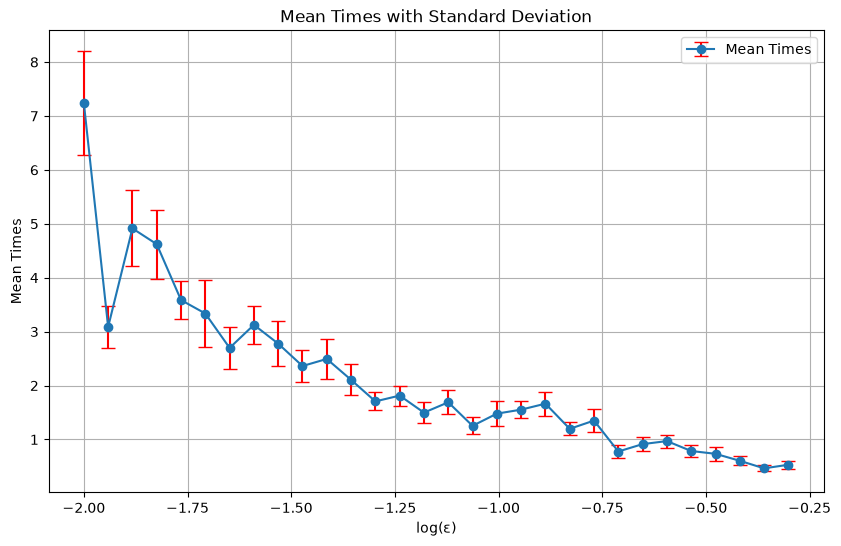

In [20]:
x_axis = np.logspace(np.log10(0.5), np.log10(0.01), num=30, endpoint=True)
mean_escape_times = []
dev_escape_times = []

# Equal epsilon
for epsilon in tqdm(x_axis, desc="Sizes"):
    escape_times = []
    exit_points = []

    
    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation_2d)(epsilon, epsilon)
        for _ in range(50)
    )

    for escape_point, escape_time in results:
        if escape_point is not None:
            escape_times.append(escape_time)
            exit_points.append(escape_point)

    escape_times = np.array(escape_times)
    exit_points = np.array(exit_points)

    mean_escape_time = np.mean(escape_times)
    mean_escape_times.append(mean_escape_time)

    dev_escape_time = np.std(escape_times)
    dev_escape_times.append(dev_escape_time / np.sqrt(len(escape_times)))  # Standard error of the mean

Statistics.plot_mean_times(np.log10(x_axis), mean_escape_times, dev_escape_times, xlabel='log(ε)')

## Simulation for different shapes

Escape time: 1.5975000000000001


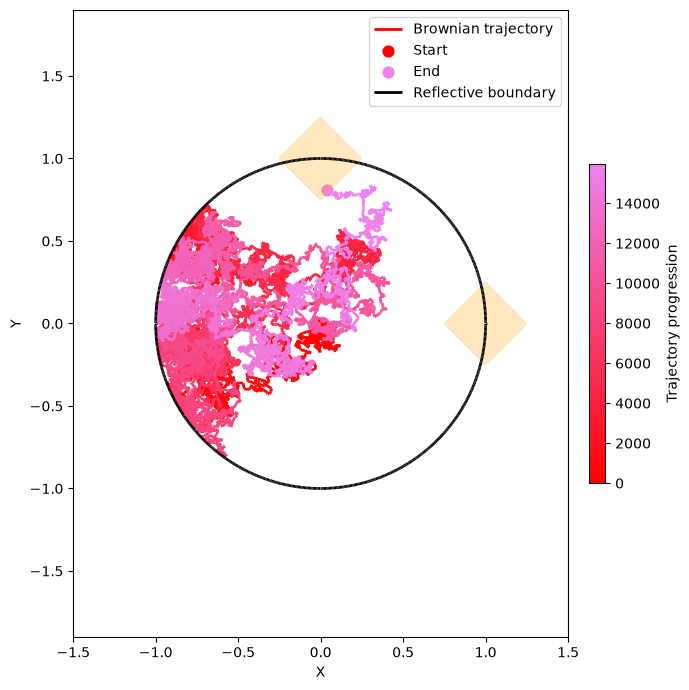

In [6]:
import numpy as np
from stage_escape.brownian import BrownianMotion
from stage_escape.surface import Surface
from stage_escape.equivalent_narrow_escape import EquivalentNarrowEscape
from stage_escape.escape import Escape

bm = BrownianMotion(deposition_stride=deposition_stride, delta_t=DELTA_T, dimension=DIMENSION, seed=SEED)

# Surface defined by the equation x^2 + y^2 = 1 (unit circle)
surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

point1 = np.array([1, 0])
escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** 1) <= (0.5 / 2) ** 1]) # Escape region

point2 = np.array([0, 1])
escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** 1) <= (0.5 / 2) ** 1])

narrow_escape = EquivalentNarrowEscape(bm, surface, [escape1, escape2])

escape_point, escape_time = narrow_escape.run_simulation()
print(f'Escape time: {escape_time}')
narrow_escape.plot_narrow_escape_problem()

In [8]:
def run_one_simulation_2d_pow(epsilon1, epsilon2, power):
    bm = BrownianMotion(deposition_stride=deposition_stride, delta_t=DELTA_T, dimension=DIMENSION)

    # Surface defined by the equation x^2 + y^2 = 1 (unit circle)
    surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

    point1 = np.array([1, 0])
    escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** power) <= (epsilon1 / 2) ** power]) # Escape region

    point2 = np.array([-1, 0])
    escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** power) <= (epsilon2 / 2) ** power])

    narrow_escape = EquivalentNarrowEscape(bm, surface, [escape1, escape2])

    escape_point, escape_time = narrow_escape.run_simulation()
    return escape_point, escape_time

Exponents:   0%|          | 0/19 [00:00<?, ?it/s]

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

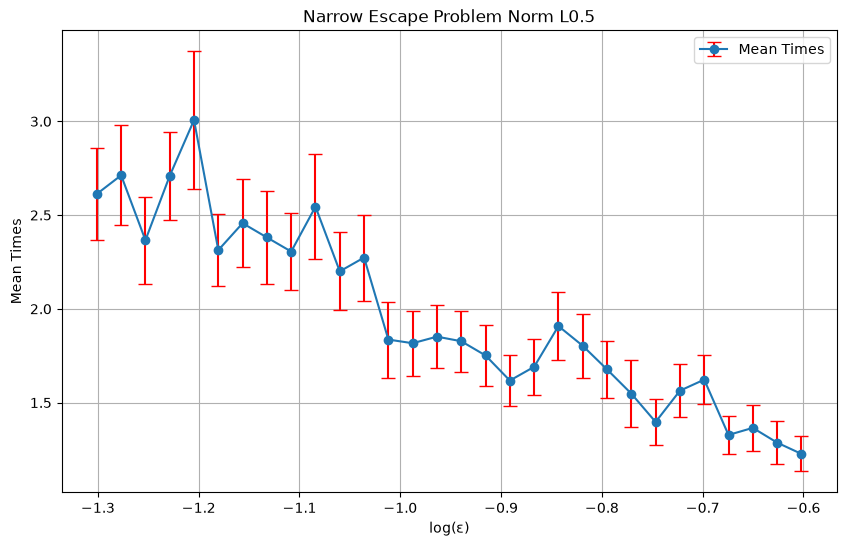

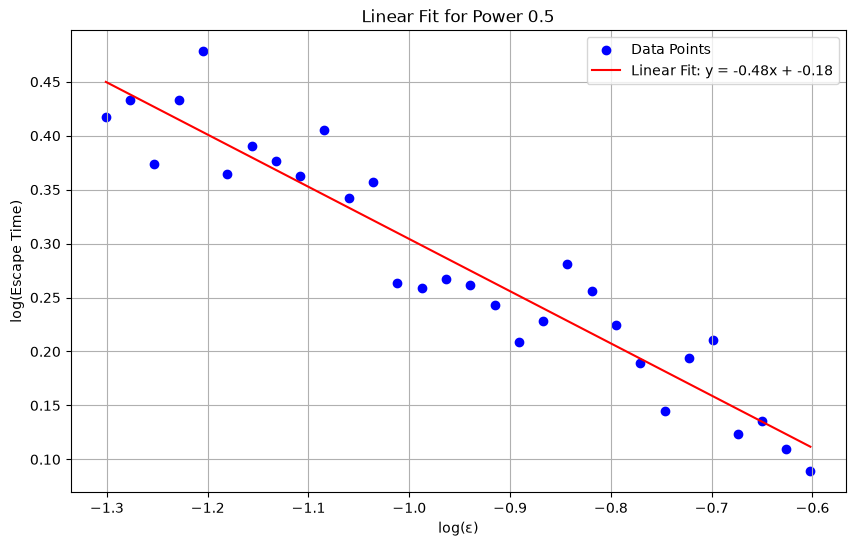

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

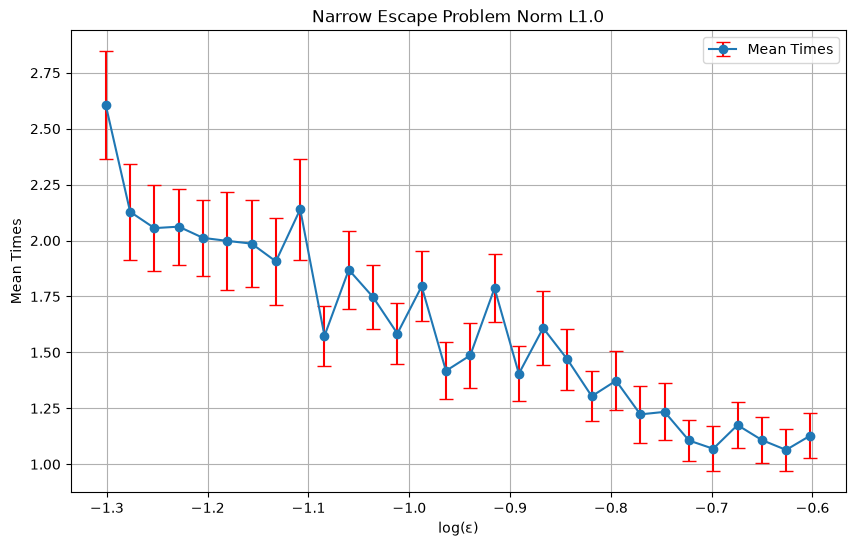

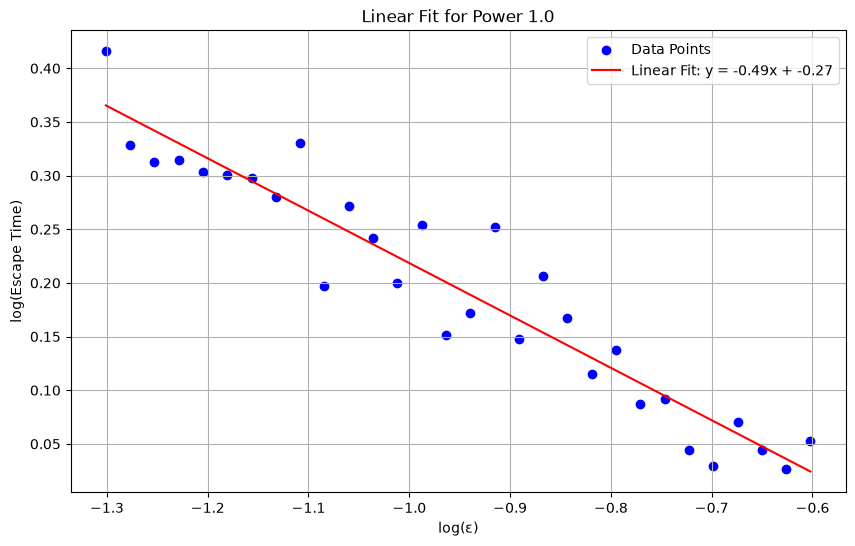

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

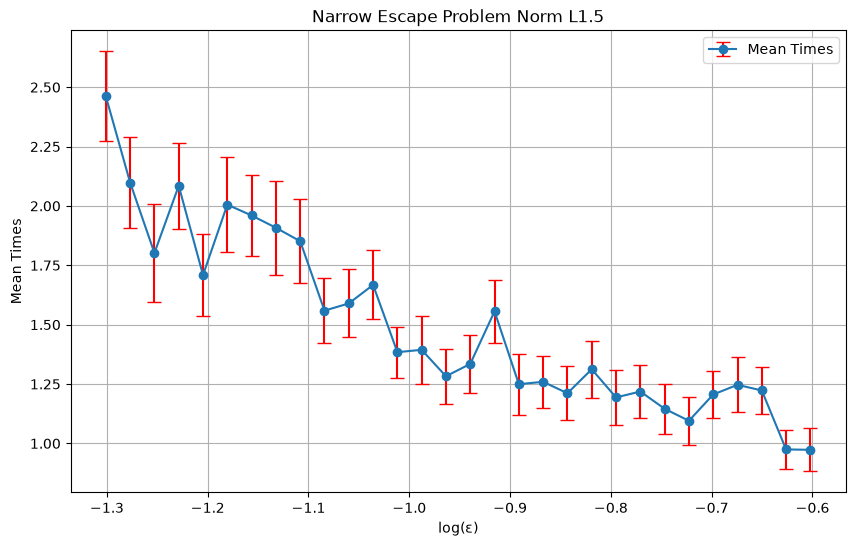

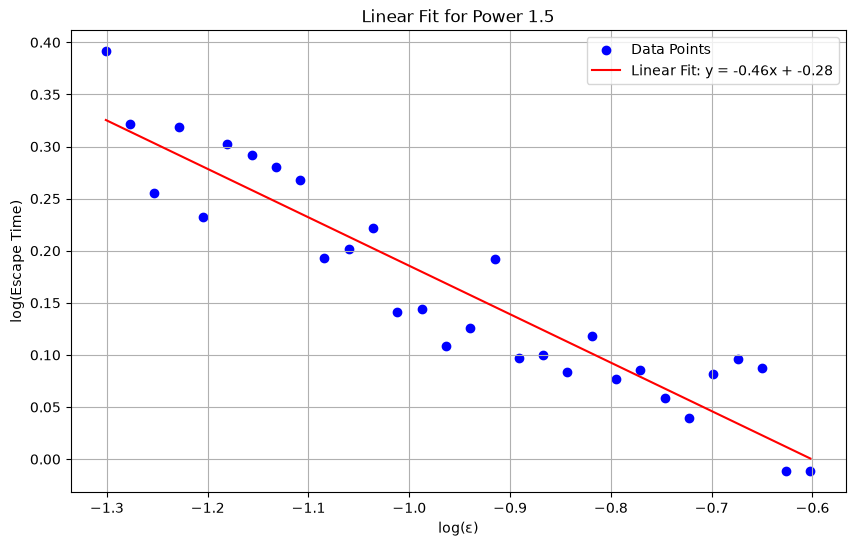

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

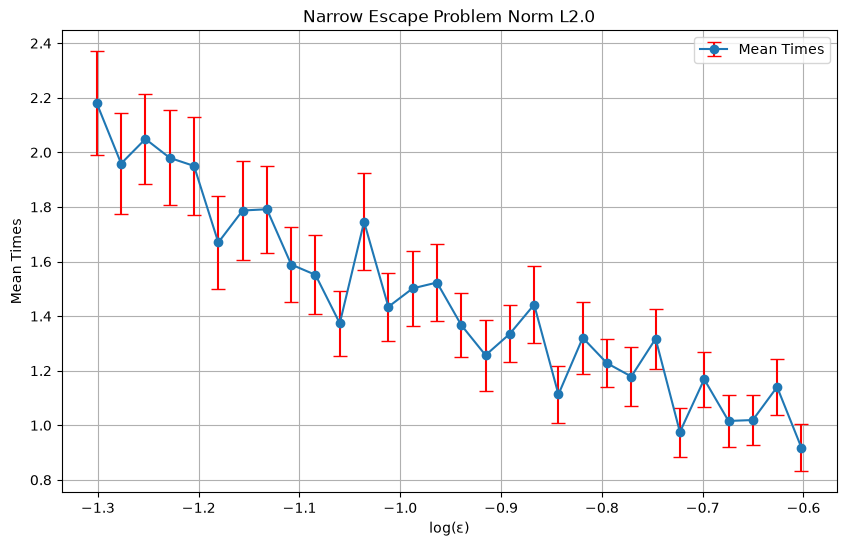

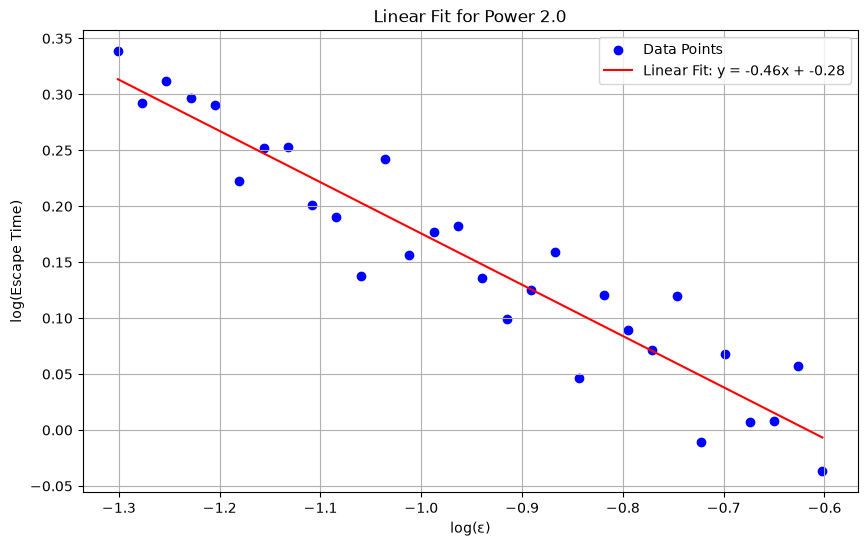

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

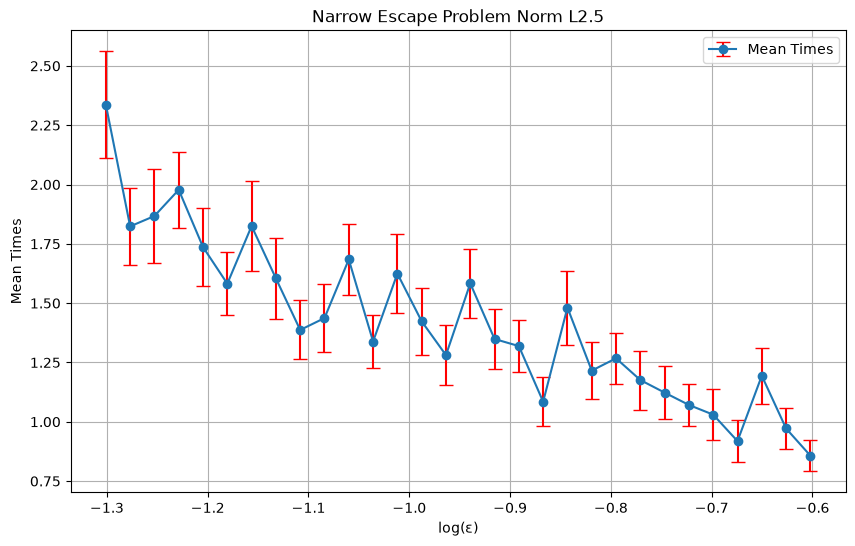

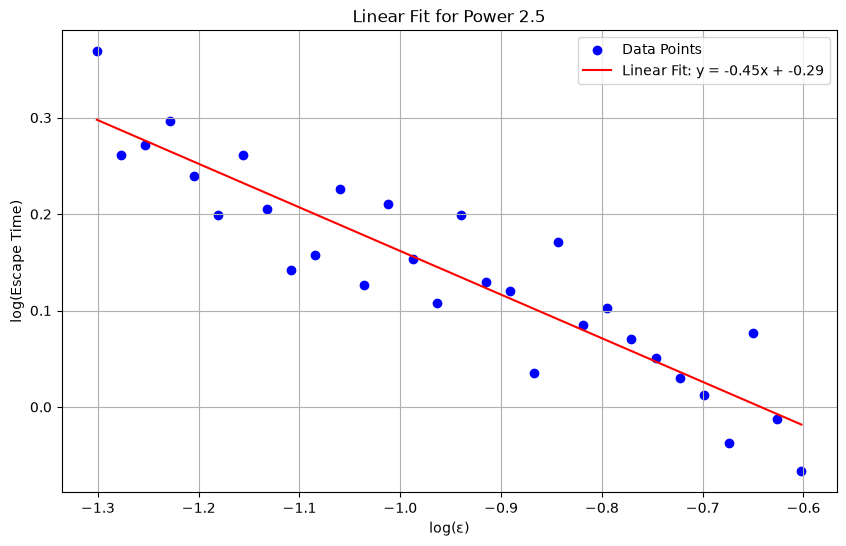

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

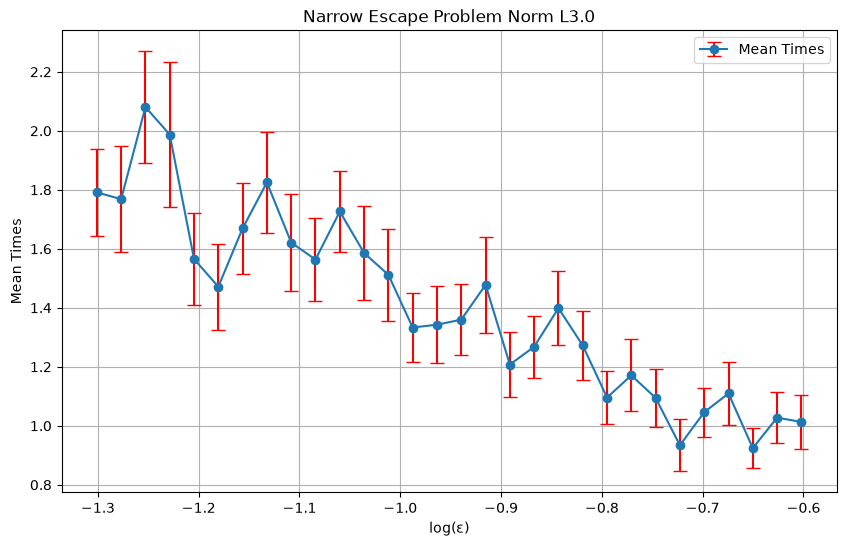

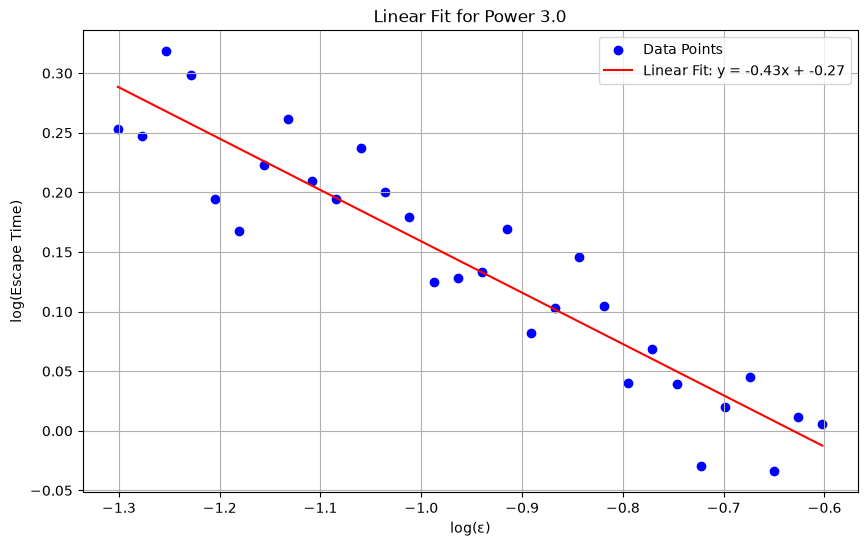

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

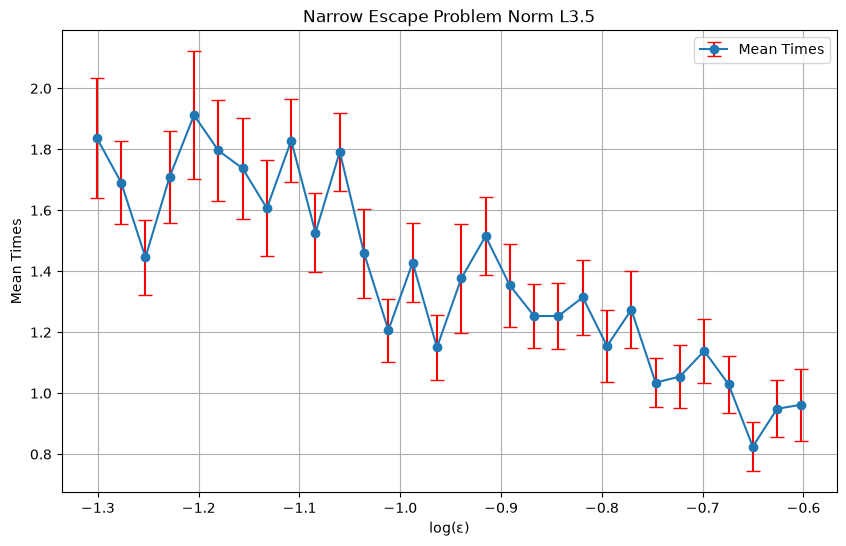

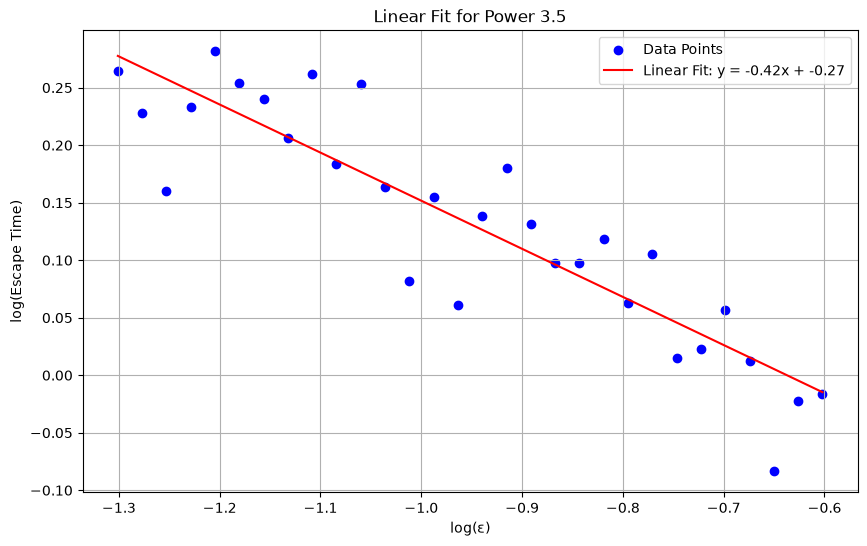

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

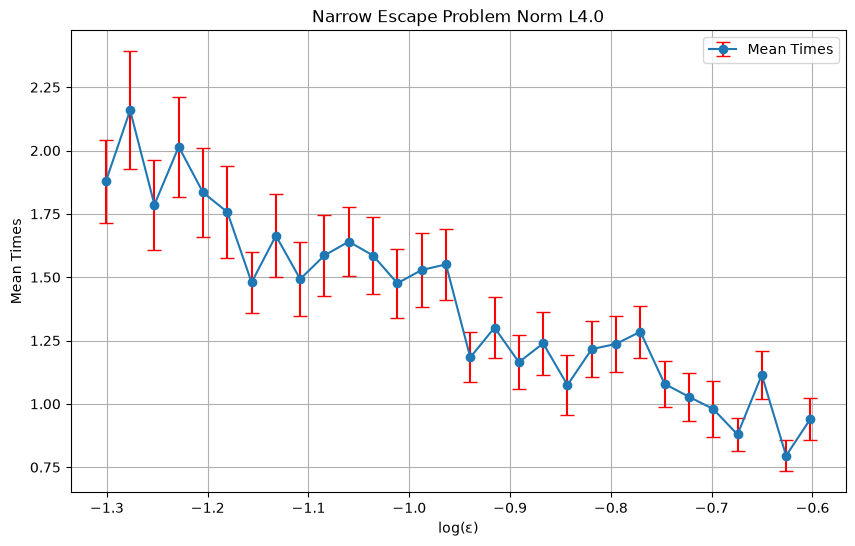

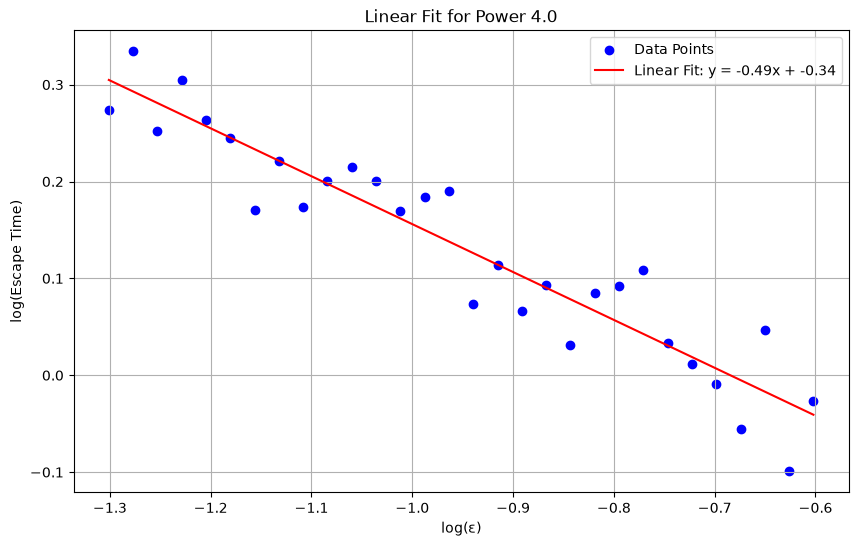

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

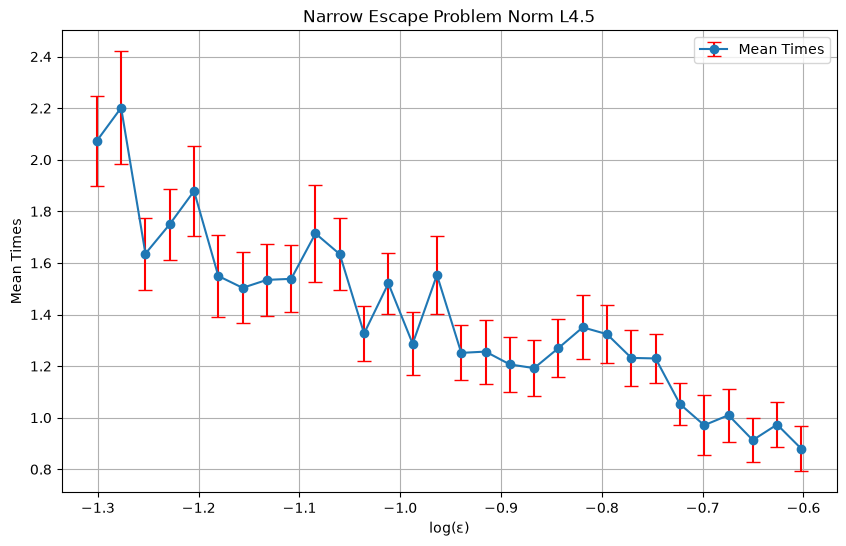

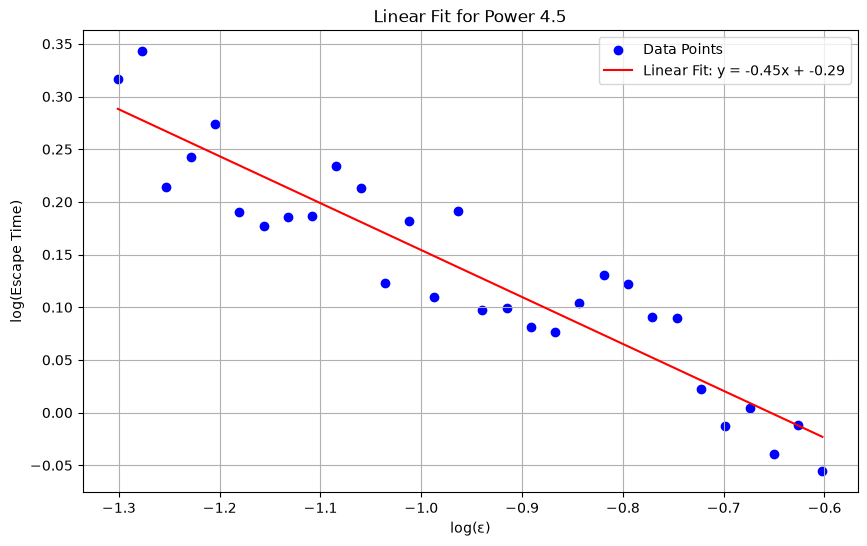

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

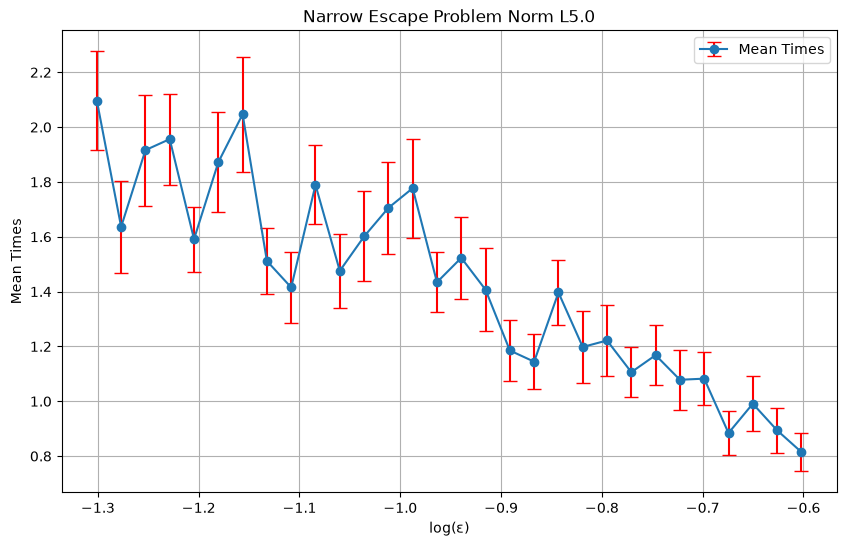

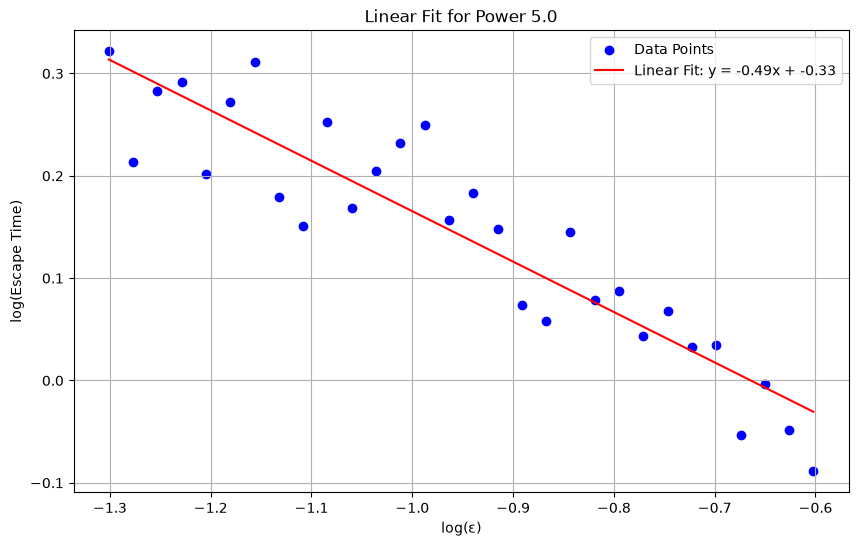

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

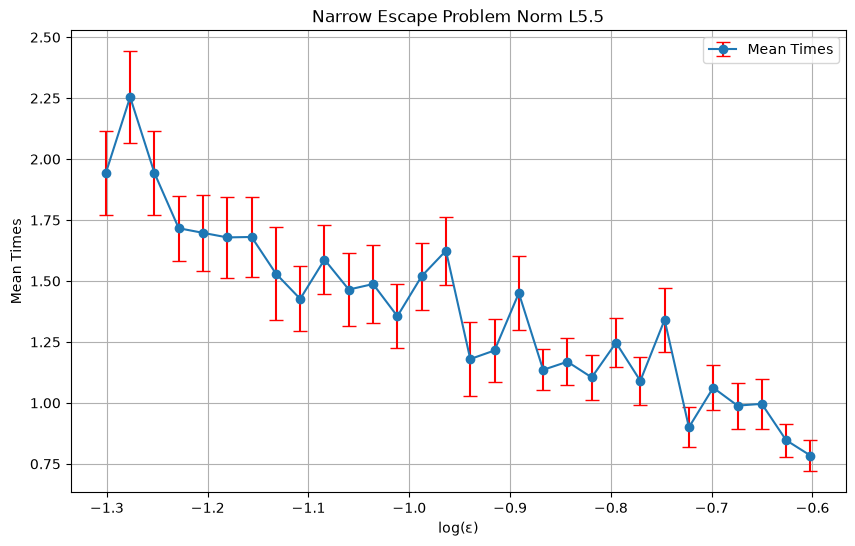

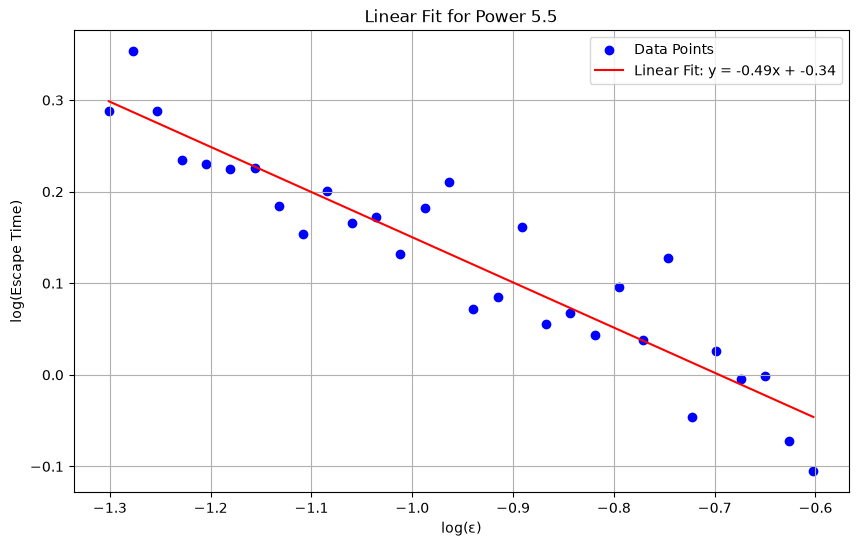

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

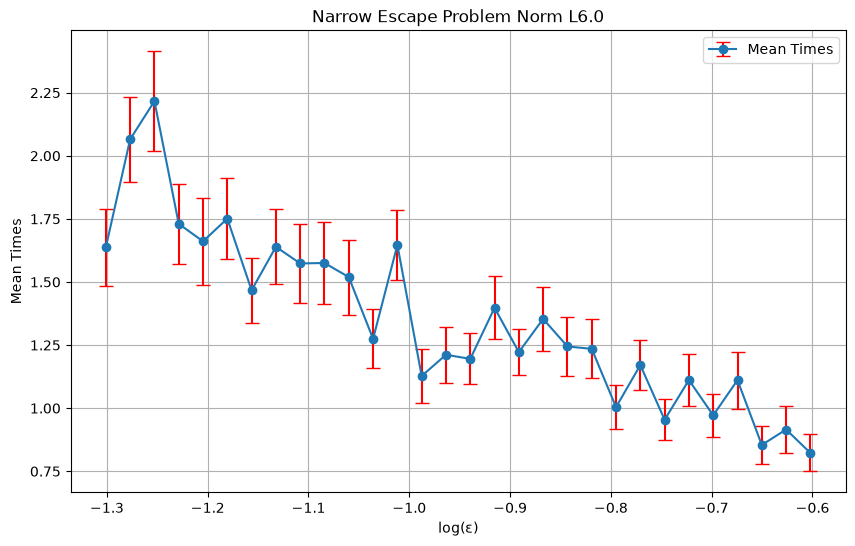

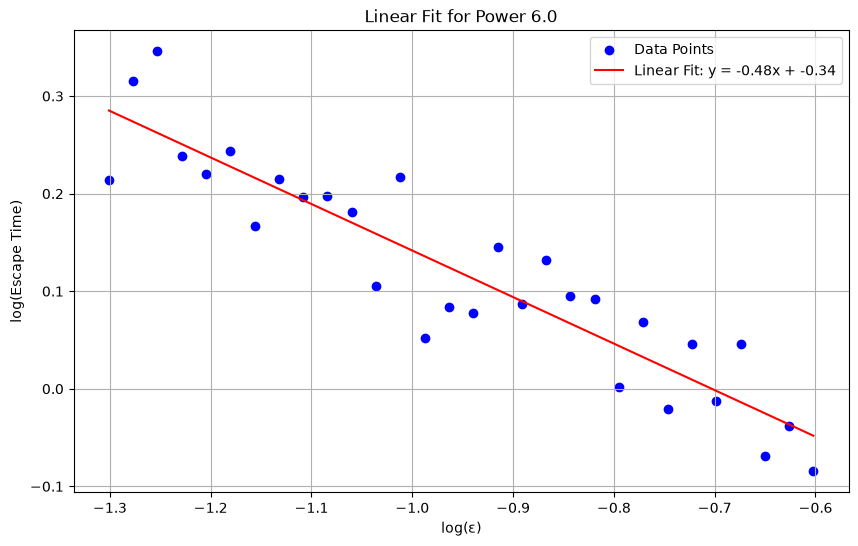

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

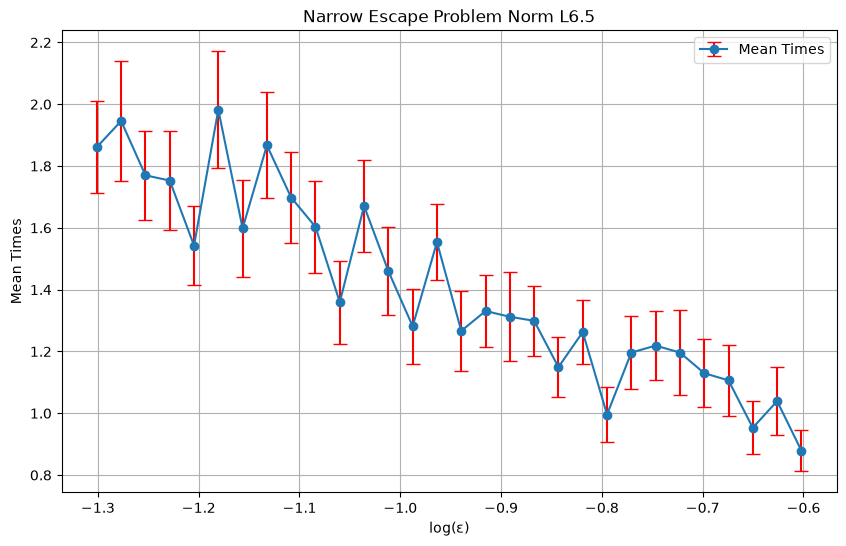

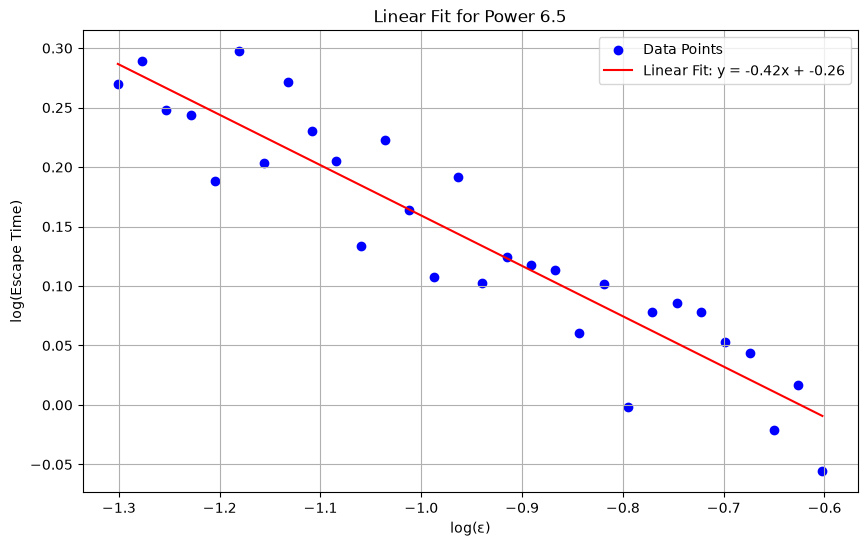

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

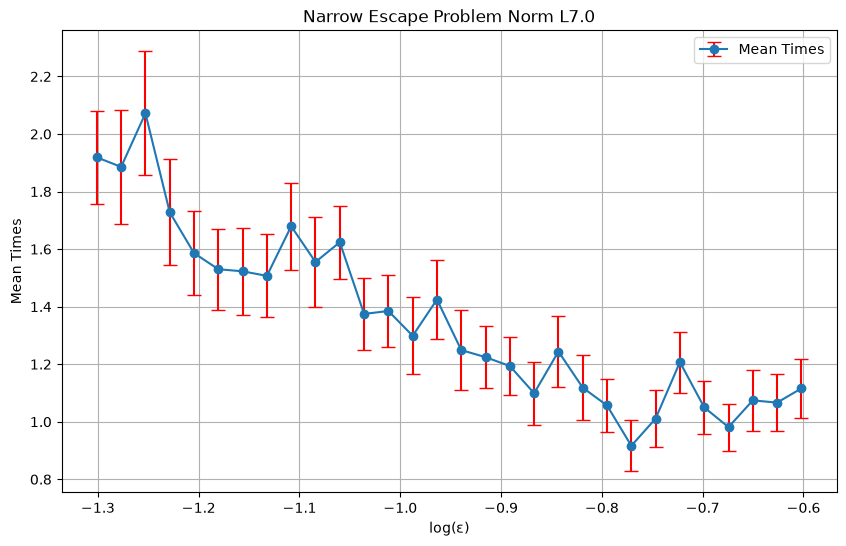

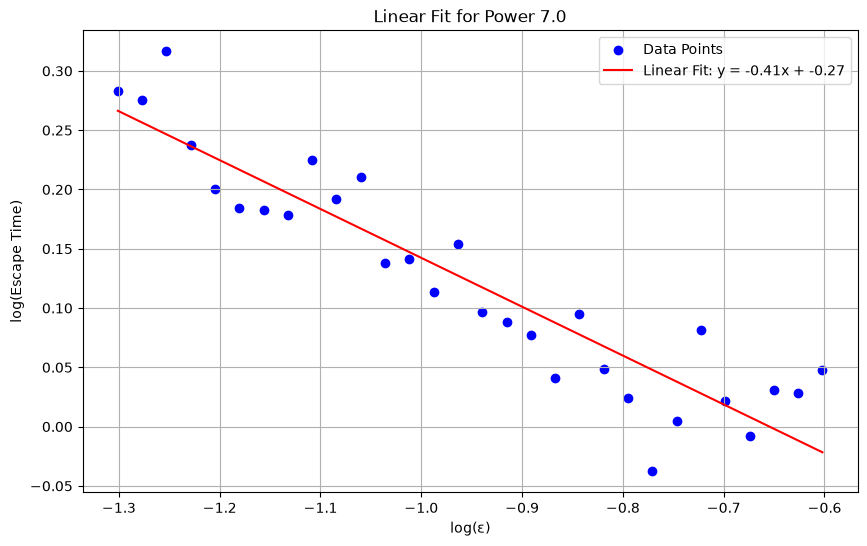

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

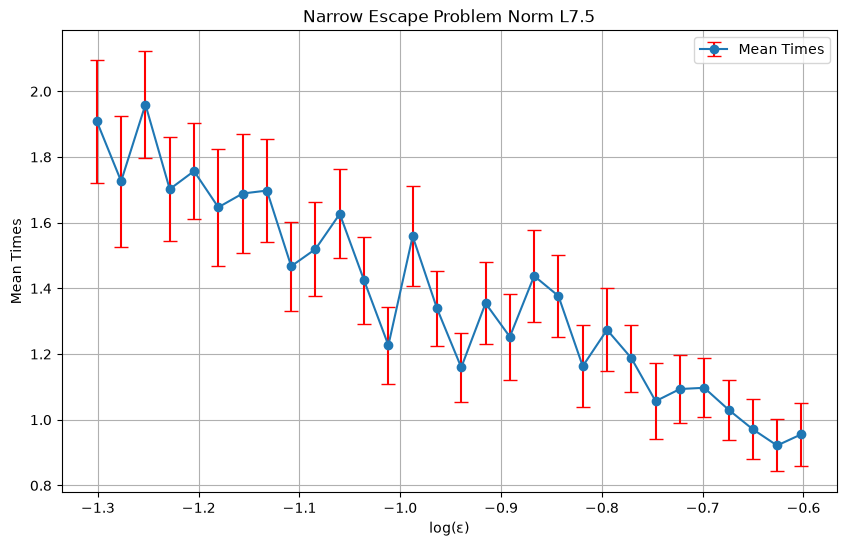

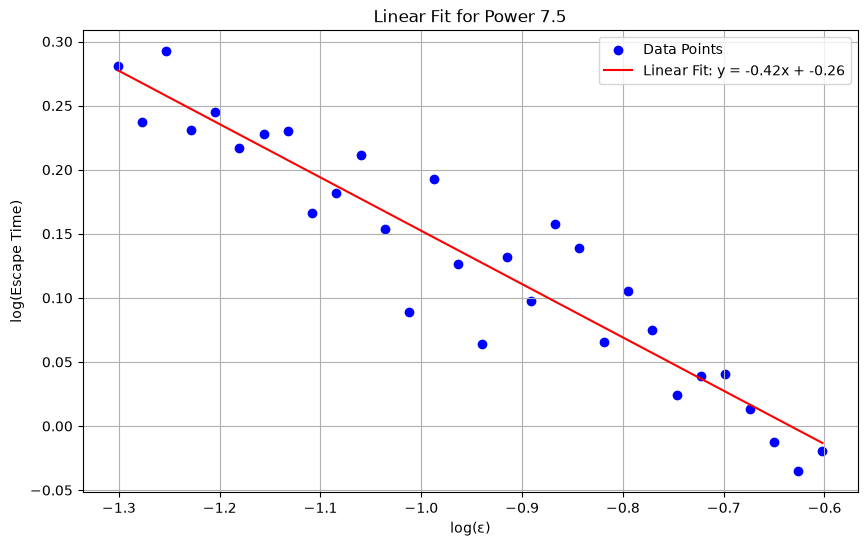

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

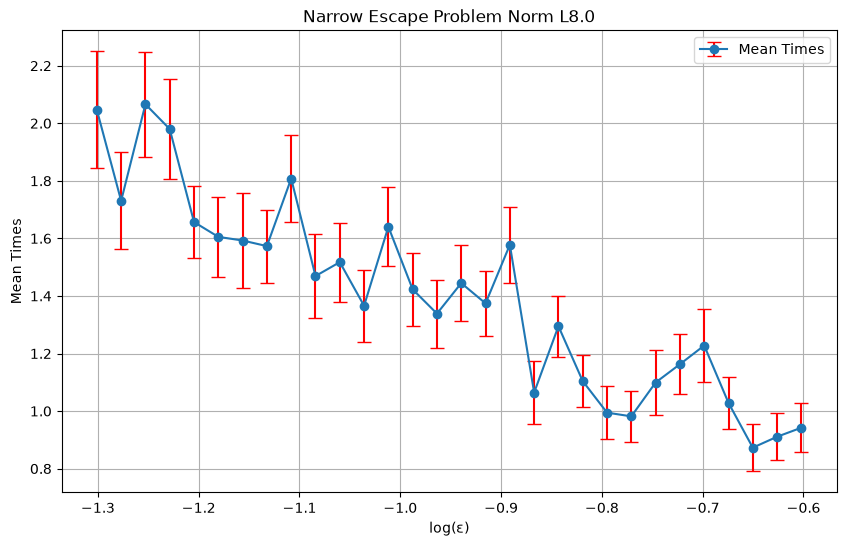

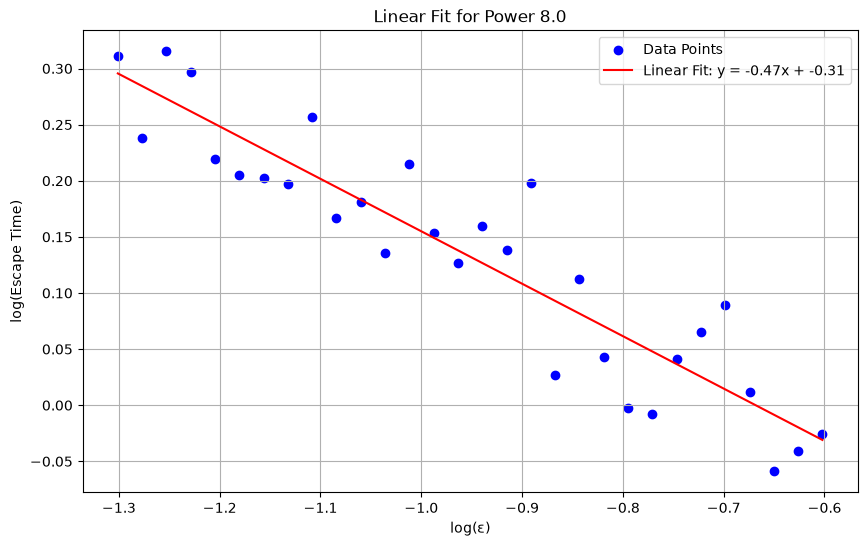

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

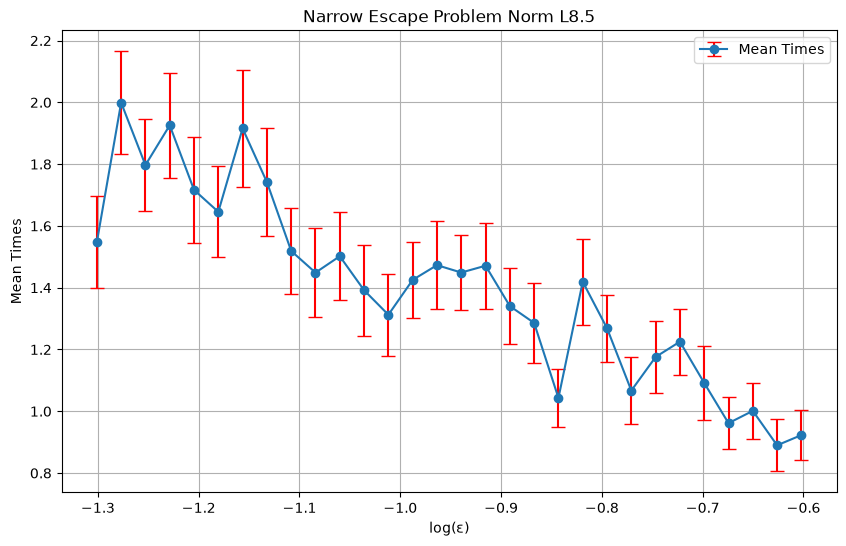

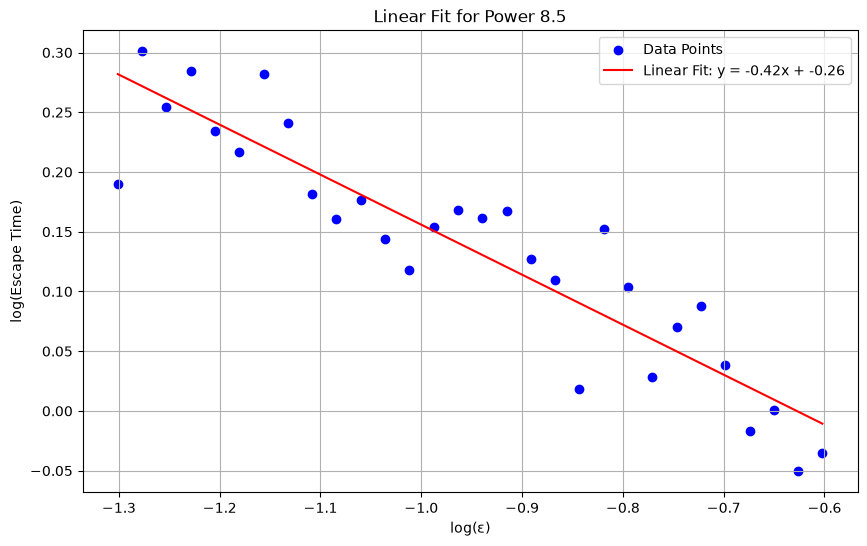

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

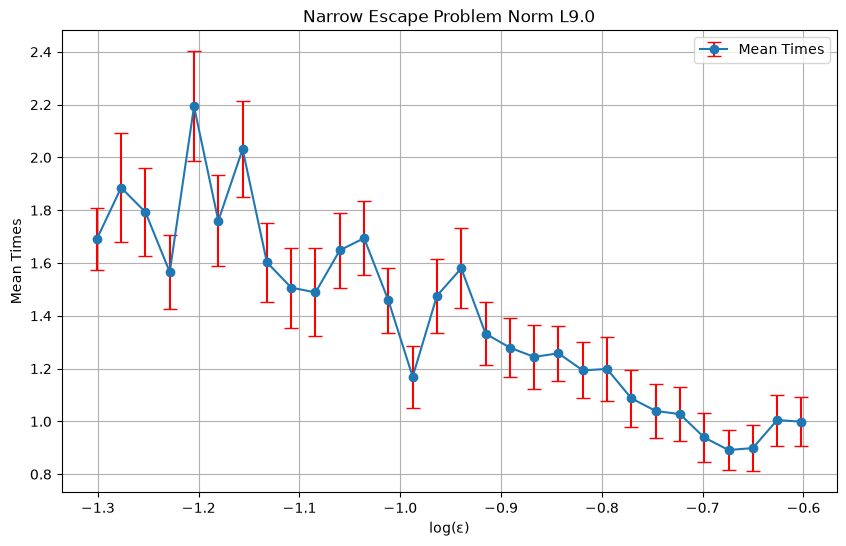

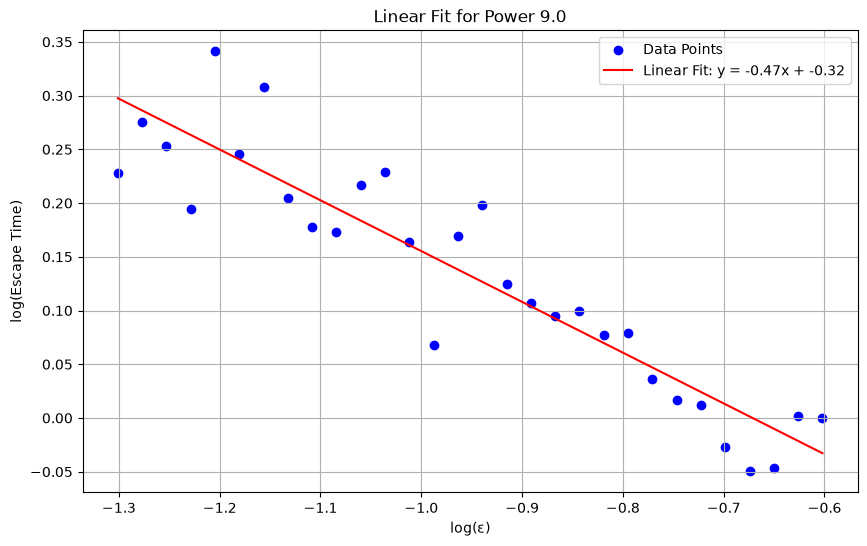

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

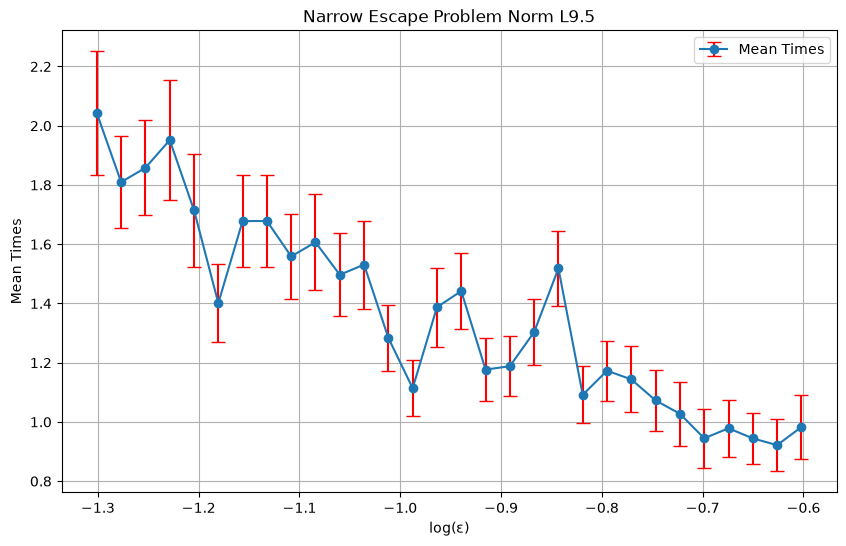

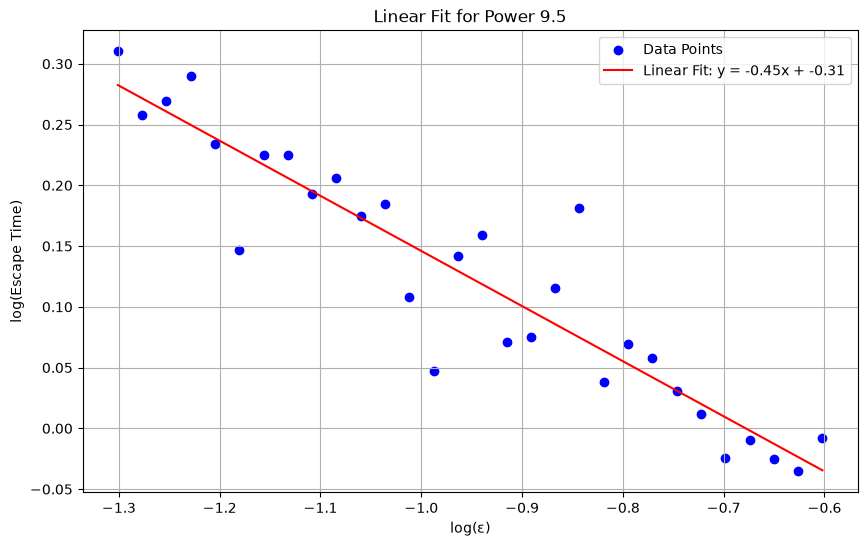

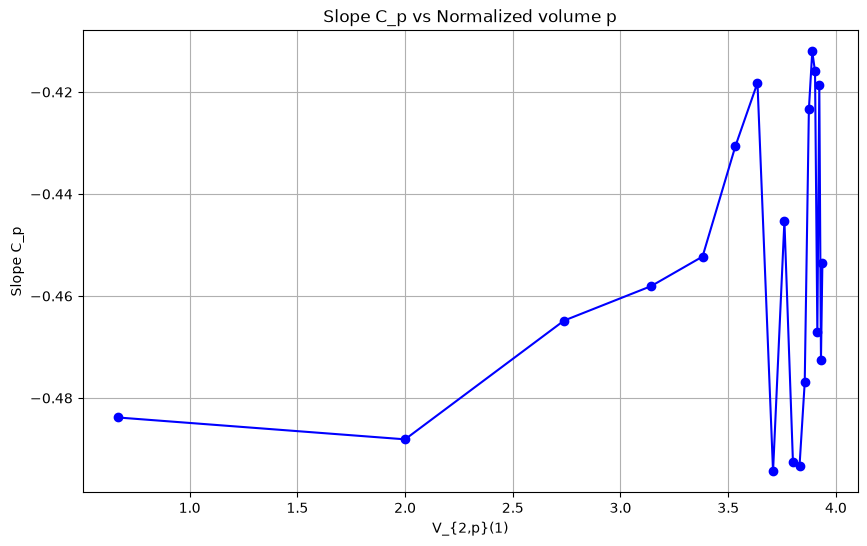

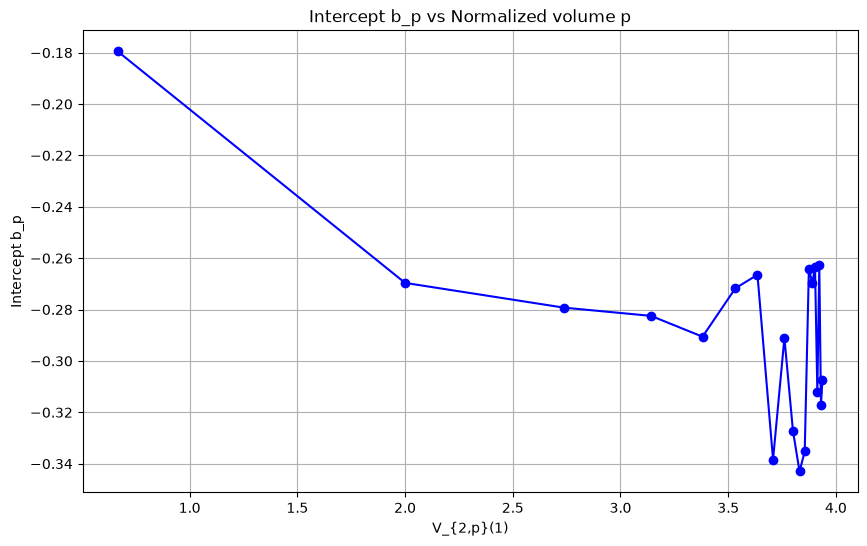

In [9]:
powers = np.arange(0.5, 10, 0.5)  # Powers from 1 to 9.5 with step of 0.5
inverse_powers = 1 / powers
gamma_p = (2 * gamma(1 + 1 / powers)) ** 2 / gamma(1 + 2 / powers)  # This is the correct formula for gamma_p
list_C_p = []
list_b_p = []

for power in tqdm(powers, desc="Exponents"):
    x_axis = np.logspace(np.log10(0.25), np.log10(0.05), num=30, endpoint=True)
    mean_escape_times = []
    dev_escape_times = []

    # Equal epsilon
    for epsilon in tqdm(x_axis, desc="Sizes"):
        escape_times = []
        exit_points = []

        
        results = Parallel(n_jobs=-1)(
            delayed(run_one_simulation_2d_pow)(epsilon, epsilon, power)
            for _ in range(100)
        )

        for escape_point, escape_time in results:
            if escape_point is not None:
                escape_times.append(escape_time)
                exit_points.append(escape_point)

        escape_times = np.array(escape_times)
        exit_points = np.array(exit_points)

        mean_escape_time = np.mean(escape_times)
        mean_escape_times.append(mean_escape_time)

        dev_escape_time = np.std(escape_times)
        dev_escape_times.append(dev_escape_time / np.sqrt(len(escape_times)))  # Standard error of the mean

    C_p, b_p = np.polyfit(np.log10(x_axis), np.log10(mean_escape_times), 1)
    list_C_p.append(C_p)
    list_b_p.append(b_p)
    Statistics.plot_mean_times(np.log10(x_axis), mean_escape_times, dev_escape_times, xlabel='log(ε)', title=f'Narrow Escape Problem Norm L{power}')
    Statistics.plot_graph_and_linear_adjustment(np.log10(x_axis), np.log10(mean_escape_times), xlabel='log(ε)', ylabel='log(Escape Time)', title=f'Linear Fit for Power {power}')

Statistics.simple_plot(gamma_p, list_C_p, xlabel='V_{2,p}(1)', ylabel='Slope C_p', title='Slope C_p vs Normalized volume p')
Statistics.simple_plot(gamma_p, list_b_p, xlabel='V_{2,p}(1)', ylabel='Intercept b_p', title='Intercept b_p vs Normalized volume p')